# Notebook 12 — SEI-only Cycling + RPT Fingerprint

## Goal

This notebook extends the SEI-only entry audit into a short cycling + RPT fingerprint study.

The goal is to test whether SEI-only aging produces observable diagnostic drift in:

- capacity,
- Ri_CD / Ri_EF,
- tau1 / tau2 relaxation descriptors,
- SEI thickness,
- loss of lithium inventory,
- lithium lost to side reactions,
- side-reaction capacity loss.

## Scientific context

Notebook 11 confirmed that the SEI-only branch is runnable using:

- parameter set: `OKane2022`
- SEI option: `solvent-diffusion limited`
- lithium plating: disabled
- loss of active material: disabled
- particle mechanics: disabled
- SEI porosity change: disabled

Notebook 11 also confirmed that SEI-related variables are accessible and evolve during a one-cycle smoke test.

The next question is:

Does SEI-only aging project mainly into:

1. a capacity / LLI fingerprint,
2. an Ri-sensitive fingerprint,
3. a tau-sensitive fingerprint,
4. or a mixed observable signature?

## Study design

This notebook performs a short proof-of-concept aging study.

The workflow is:

1. Run a short SEI-only cycling block.
2. Extract degradation variables after the aging block.
3. Run RPT-style HPPC checks at selected aging states.
4. Extract:
   - CDEFG points,
   - Ri_CD / Ri_EF,
   - tau1 / tau2 descriptors,
   - capacity-related observables,
   - SEI / LLI variables.
5. Compare diagnostic drift relative to the initial state.

## Important design boundary

This notebook is not a full lifetime aging simulation.

It is an engineering proof-of-concept to verify whether the SEI-only degradation pathway can be connected to the existing HPPC fingerprint extraction pipeline.

The observed aging rate should not be interpreted as a validated real-cell SEI aging rate.

## Expected outputs

- `data/sei_only_cycling_trace.csv`
- `data/sei_only_rpt_fingerprint_table.csv`
- `data/sei_only_degradation_state_table.csv`
- SEI growth plots
- capacity / LLI drift plots
- Ri / tau drift plots

## Interpretation boundary

This notebook only tests the workflow:

SEI-only degradation model  
→ cycling-induced degradation variables  
→ RPT / HPPC observable drift  
→ diagnostic fingerprint classification

The correct conclusion format is:

“Under this short SEI-only proof-of-concept protocol, SEI growth produces observable drift mainly in X, Y, and Z.”

It must not claim a validated aging law or a real-cell SOH trajectory.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — SEI-only model configuration（SEI-only 模型配置）

PARAMETER_SET = "OKane2022"
SEI_OPTION = "solvent-diffusion limited"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

param = pybamm.ParameterValues(PARAMETER_SET)
model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)

print("Parameter set:", PARAMETER_SET)
print("SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

Parameter set: OKane2022
SEI option: solvent-diffusion limited
Model options: {'SEI': ('solvent-diffusion limited', 'none'), 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}


In [3]:
# Cell 3 — Shared extraction configuration（RPT/HPPC 提取配置）

RPT_SOC = 0.50
HPPC_PULSE_C_RATE = "1C"
HPPC_PULSE_DURATION_S = 10
HPPC_REST_BEFORE_S = 60
HPPC_RELAXATION_S = 600
HPPC_OUTPUT_PERIOD = "0.1 seconds"

print("RPT_SOC:", RPT_SOC)
print("HPPC pulse:", HPPC_PULSE_C_RATE, "for", HPPC_PULSE_DURATION_S, "s")
print("HPPC rest before:", HPPC_REST_BEFORE_S, "s")
print("HPPC relaxation:", HPPC_RELAXATION_S, "s")
print("HPPC output period:", HPPC_OUTPUT_PERIOD)

RPT_SOC: 0.5
HPPC pulse: 1C for 10 s
HPPC rest before: 60 s
HPPC relaxation: 600 s
HPPC output period: 0.1 seconds


In [4]:
# Cell 4 — Degradation variable selection（选择 SEI / LLI / capacity 老化变量）

degradation_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
    "sei_interfacial_current_A_m2": [
        "X-averaged negative electrode SEI interfacial current density [A.m-2]",
        "X-averaged SEI interfacial current density [A.m-2]",
    ],
}


def first_available_variable(solution_or_model, candidates, mode="solution"):
    """
    Return first available variable from candidate names.

    mode="model": check model.variables
    mode="solution": check solution variable access
    """
    for name in candidates:
        try:
            if mode == "model":
                _ = solution_or_model.variables[name]
            else:
                _ = solution_or_model[name].entries
            return name
        except Exception:
            pass
    return None


selected_model_variables = {}

for short_name, candidates in degradation_variable_candidates.items():
    selected = first_available_variable(model, candidates, mode="model")
    selected_model_variables[short_name] = selected

selected_model_variables

{'sei_thickness_m': 'X-averaged negative SEI thickness [m]',
 'loss_lithium_inventory_pct': 'Loss of lithium inventory [%]',
 'total_lithium_lost_mol': 'Total lithium lost [mol]',
 'capacity_lost_side_reactions_Ah': 'Total capacity lost to side reactions [A.h]',
 'sei_interfacial_current_A_m2': 'X-averaged negative electrode SEI interfacial current density [A.m-2]'}

In [5]:
# Cell 5 — Aging block smoke protocol（短周期 SEI-only aging block 冒烟测试）

N_CYCLES_SMOKE = 3

cycle_steps = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

experiment_steps = cycle_steps * N_CYCLES_SMOKE

aging_experiment = pybamm.Experiment(
    experiment_steps,
    period="120 seconds",
)

print("Number of smoke cycles:", N_CYCLES_SMOKE)
print("Number of experiment steps:", len(experiment_steps))
print("Output period: 120 seconds")

Number of smoke cycles: 3
Number of experiment steps: 15
Output period: 120 seconds


In [6]:
# Cell 6 — Run short SEI-only cycling smoke test（运行短周期 SEI-only cycling）

sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=aging_experiment,
)

sim.set_initial_soc(1.0, direction="discharge")

aging_solution = sim.solve()

print("[OK] short SEI-only cycling solved")
print("Termination:", aging_solution.termination)
print("Final time [h]:", float(aging_solution["Time [h]"].entries[-1]))

[OK] short SEI-only cycling solved
Termination: final time
Final time [h]: 21.358301790137954


In [7]:
# Cell 7 — Extract cycling degradation trace（提取短周期 cycling 的老化变量）

aging_trace = pd.DataFrame(
    {
        "time_s": aging_solution["Time [s]"].entries,
        "time_h": aging_solution["Time [h]"].entries,
        "voltage_V": aging_solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": aging_solution["Current [A]"].entries,
        "discharge_capacity_Ah": aging_solution["Discharge capacity [A.h]"].entries,
        "throughput_capacity_Ah": aging_solution["Throughput capacity [A.h]"].entries,
    }
)

aging_trace["current_A_exp"] = -aging_trace["current_A_pybamm"]

selected_solution_variables = {}

for short_name, candidates in degradation_variable_candidates.items():
    selected = first_available_variable(aging_solution, candidates, mode="solution")
    selected_solution_variables[short_name] = selected

    if selected is None:
        print(f"[WARN] No variable found for {short_name}")
        continue

    values = np.asarray(aging_solution[selected].entries)

    if values.ndim == 1:
        trace = values
    else:
        trace = np.mean(values, axis=0)

    aging_trace[short_name] = trace
    print(f"[OK] extracted {short_name} from {selected}")

out_csv = DATA / "sei_only_short_cycling_trace.csv"
aging_trace.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aging_trace.head())
display(aging_trace.tail())

[OK] extracted sei_thickness_m from X-averaged negative SEI thickness [m]
[OK] extracted loss_lithium_inventory_pct from Loss of lithium inventory [%]
[OK] extracted total_lithium_lost_mol from Total lithium lost [mol]
[OK] extracted capacity_lost_side_reactions_Ah from Total capacity lost to side reactions [A.h]
[OK] extracted sei_interfacial_current_A_m2 from X-averaged negative electrode SEI interfacial current density [A.m-2]
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_short_cycling_trace.csv


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,current_A_exp,sei_thickness_m,loss_lithium_inventory_pct,total_lithium_lost_mol,capacity_lost_side_reactions_Ah,sei_interfacial_current_A_m2
0,0.0,0.000000,4.130157,1.666667,0.000000,0.000000,-1.666667,5.000000e-09,1.421085e-13,-5.551115e-17,0.000000,-0.000013
1,120.0,0.033333,4.066202,1.666667,0.055556,0.055556,-1.666667,5.001516e-09,1.870937e-05,5.312828e-08,0.000001,-0.000013
2,240.0,0.066667,4.046906,1.666667,0.111111,0.111111,-1.666667,5.003031e-09,3.741308e-05,1.062405e-07,0.000003,-0.000013
3,360.0,0.100000,4.036433,1.666667,0.166667,0.166667,-1.666667,5.004546e-09,5.611113e-05,1.593366e-07,0.000004,-0.000013
4,480.0,0.133333,4.031603,1.666667,0.222222,0.222222,-1.666667,5.006060e-09,7.480348e-05,2.124165e-07,0.000006,-0.000013


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,current_A_exp,sei_thickness_m,loss_lithium_inventory_pct,total_lithium_lost_mol,capacity_lost_side_reactions_Ah,sei_interfacial_current_A_m2
652,76409.886444,21.224968,4.195725,0.0,0.011609,30.23733,-0.0,5.886670e-09,0.010945,0.000031,0.000833,-0.000011
653,76529.886444,21.258302,4.195230,0.0,0.011609,30.23733,-0.0,5.887957e-09,0.010960,0.000031,0.000834,-0.000011
654,76649.886444,21.291635,4.194937,0.0,0.011609,30.23733,-0.0,5.889245e-09,0.010976,0.000031,0.000835,-0.000011
655,76769.886444,21.324968,4.194743,0.0,0.011609,30.23733,-0.0,5.890532e-09,0.010992,0.000031,0.000837,-0.000011
656,76889.886444,21.358302,4.194614,0.0,0.011609,30.23733,-0.0,5.891818e-09,0.011008,0.000031,0.000838,-0.000011


In [8]:
# Cell 8 — Cycling degradation delta summary（短周期 cycling 老化变量变化总结）

delta_rows = []

for col in aging_trace.columns:
    if col in [
        "time_s",
        "time_h",
        "voltage_V",
        "current_A_pybamm",
        "current_A_exp",
    ]:
        continue

    start_val = float(aging_trace[col].iloc[0])
    end_val = float(aging_trace[col].iloc[-1])
    delta = end_val - start_val

    if abs(start_val) > 1e-30:
        rel_pct = 100 * delta / start_val
    else:
        rel_pct = np.nan

    delta_rows.append(
        {
            "observable": col,
            "start_value": start_val,
            "end_value": end_val,
            "delta": delta,
            "relative_change_pct": rel_pct,
        }
    )

cycling_delta_summary = pd.DataFrame(delta_rows)

out_csv = DATA / "sei_only_short_cycling_delta_summary.csv"
cycling_delta_summary.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(cycling_delta_summary)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_short_cycling_delta_summary.csv


,observable,start_value,end_value,delta,relative_change_pct
0,discharge_capacity_Ah,0.000000e+00,1.160860e-02,1.160860e-02,NaN
1,throughput_capacity_Ah,0.000000e+00,3.023733e+01,3.023733e+01,NaN
2,sei_thickness_m,5.000000e-09,5.891818e-09,8.918182e-10,1.783636e+01
3,loss_lithium_inventory_pct,1.421085e-13,1.100811e-02,1.100811e-02,7.746267e+12
4,total_lithium_lost_mol,-5.551115e-17,3.125929e-05,3.125929e-05,-5.631174e+13
5,capacity_lost_side_reactions_Ah,0.000000e+00,8.377954e-04,8.377954e-04,NaN
6,sei_interfacial_current_A_m2,-1.271677e-05,-1.079189e-05,1.924880e-06,-1.513655e+01


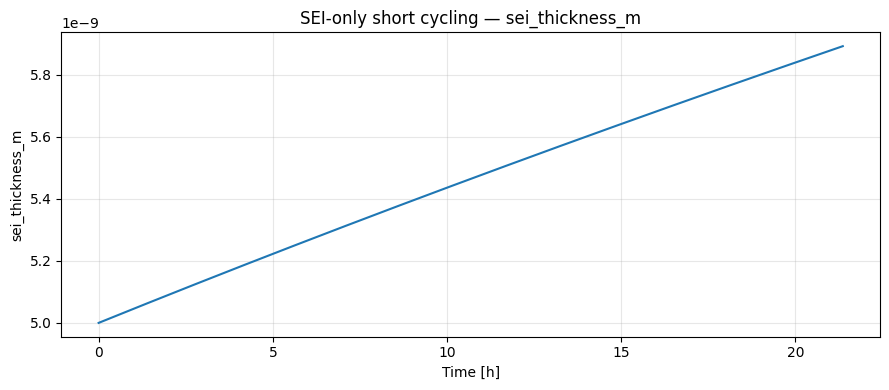

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_short_cycling_sei_thickness_m.png


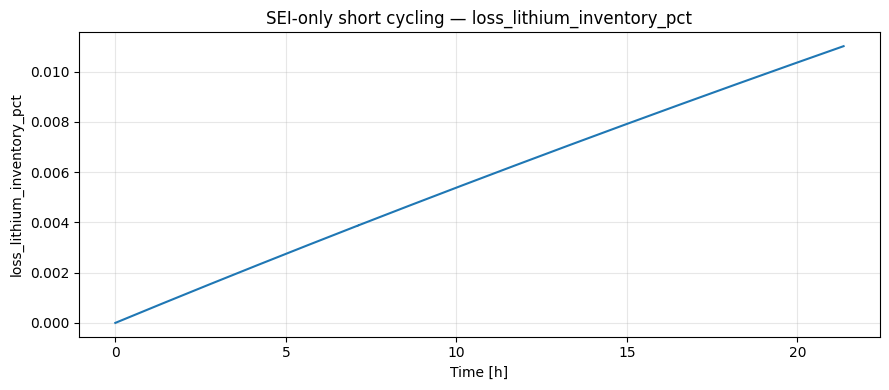

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_short_cycling_loss_lithium_inventory_pct.png


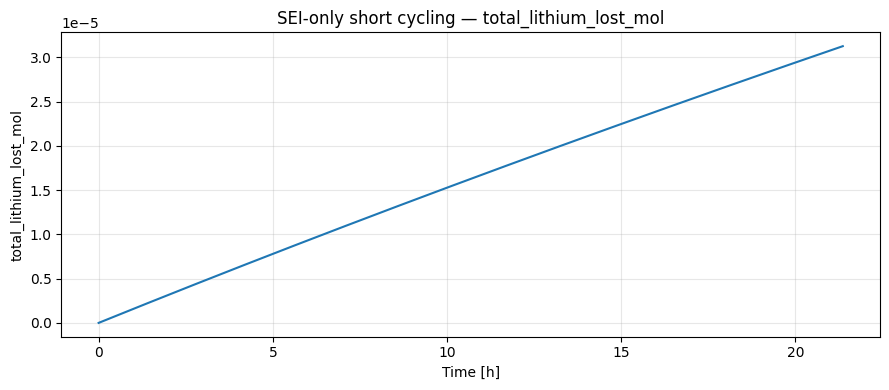

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_short_cycling_total_lithium_lost_mol.png


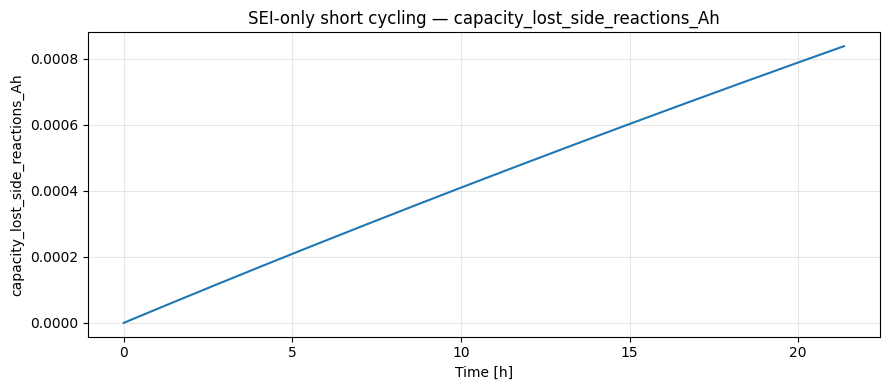

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_short_cycling_capacity_lost_side_reactions_Ah.png


In [9]:
# Cell 9 — Plot short cycling degradation variables（绘制短周期 SEI/LLI 变量变化）

plot_cols = [
    col for col in [
        "sei_thickness_m",
        "loss_lithium_inventory_pct",
        "total_lithium_lost_mol",
        "capacity_lost_side_reactions_Ah",
    ]
    if col in aging_trace.columns
]

for col in plot_cols:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(aging_trace["time_h"], aging_trace[col])
    ax.set_xlabel("Time [h]")
    ax.set_ylabel(col)
    ax.set_title(f"SEI-only short cycling — {col}")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig_path = FIGURES / f"sei_only_short_cycling_{col}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("[OK] saved:", fig_path)

In [10]:
# Cell 10 — SEI short-cycling decision table（SEI-only 短周期 cycling 决策表）

def get_delta(observable_name):
    return cycling_delta_summary.loc[
        cycling_delta_summary["observable"] == observable_name, "delta"
    ].iloc[0]

def get_end(observable_name):
    return cycling_delta_summary.loc[
        cycling_delta_summary["observable"] == observable_name, "end_value"
    ].iloc[0]

sei_cycling_decision_rows = [
    {
        "audit_item": "Short cycling solve",
        "result": "3 cycles solved to final time",
        "status": "pass",
        "interpretation": "SEI-only cycling block is numerically runnable.",
    },
    {
        "audit_item": "SEI thickness growth",
        "result": f"Δ = {get_delta('sei_thickness_m'):.3e} m",
        "status": "pass",
        "interpretation": "SEI film growth is active during cycling.",
    },
    {
        "audit_item": "Loss of lithium inventory",
        "result": f"end = {get_end('loss_lithium_inventory_pct'):.6f} %",
        "status": "pass",
        "interpretation": "LLI increases during SEI-only cycling.",
    },
    {
        "audit_item": "Total lithium lost",
        "result": f"Δ = {get_delta('total_lithium_lost_mol'):.3e} mol",
        "status": "pass",
        "interpretation": "Lithium loss variable is accessible and increases.",
    },
    {
        "audit_item": "Capacity lost to side reactions",
        "result": f"Δ = {get_delta('capacity_lost_side_reactions_Ah'):.3e} Ah",
        "status": "pass",
        "interpretation": "Side-reaction capacity loss is trackable.",
    },
    {
        "audit_item": "RPT readiness",
        "result": "ready for dedicated aged-state RPT notebook",
        "status": "pass",
        "interpretation": "Next notebook should connect aged states to HPPC/RPT extraction.",
    },
]

sei_cycling_decision_table = pd.DataFrame(sei_cycling_decision_rows)

out_csv = DATA / "sei_only_short_cycling_decision_table.csv"
sei_cycling_decision_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_cycling_decision_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_short_cycling_decision_table.csv


,audit_item,result,status,interpretation
0,Short cycling solve,3 cycles solved to final time,pass,SEI-only cycling block is numerically runnable.
1,SEI thickness growth,Δ = 8.918e-10 m,pass,SEI film growth is active during cycling.
2,Loss of lithium inventory,end = 0.011008 %,pass,LLI increases during SEI-only cycling.
3,Total lithium lost,Δ = 3.126e-05 mol,pass,Lithium loss variable is accessible and increa...
4,Capacity lost to side reactions,Δ = 8.378e-04 Ah,pass,Side-reaction capacity loss is trackable.
5,RPT readiness,ready for dedicated aged-state RPT notebook,pass,Next notebook should connect aged states to HP...


# Notebook 12 Conclusion

This notebook extended the SEI-only entry audit into a short SEI-only cycling proof-of-concept.

## Key findings

### 1. SEI-only cycling is numerically runnable

A 3-cycle SEI-only aging block was successfully solved using:

- `OKane2022`
- `SEI = solvent-diffusion limited`
- `lithium plating = none`
- `loss of active material = none`
- `particle mechanics = none`
- `SEI porosity change = false`

The experiment used repeated C/3 discharge-rest-charge-CV-rest cycling.

The simulation reached final time without numerical failure.

### 2. SEI thickness increases during cycling

The SEI thickness increased from approximately:

- `5.000e-9 m`

to approximately:

- `5.892e-9 m`

over the short cycling block.

This confirms that SEI growth is active during cycling.

### 3. Loss of lithium inventory increases

Loss of lithium inventory increased to approximately:

- `0.0110 %`

This confirms that SEI-only cycling consumes cyclable lithium and produces an LLI-type aging signal.

### 4. Lithium lost and side-reaction capacity loss increase

The model also shows increases in:

- total lithium lost,
- capacity lost to side reactions.

This confirms that SEI-only aging produces measurable degradation-state variables beyond voltage response alone.

### 5. Relative change percentages must be interpreted carefully

Some degradation variables start from values close to zero.

For variables such as:

- loss of lithium inventory,
- total lithium lost,
- capacity lost to side reactions,

absolute delta is more meaningful than relative percentage.

Large or undefined relative percentages should not be interpreted as physical aging rates.

## Interpretation boundary

This notebook does not establish a validated SEI aging law or SOH trajectory.

The observed degradation rate should not be interpreted as a real-cell aging rate.

This notebook only establishes that:

- SEI-only cycling is runnable,
- SEI/LLI/capacity-loss variables are accessible,
- these variables evolve monotonically during a short cycling block,
- the workflow is ready for a dedicated aged-state RPT / HPPC fingerprint study.

## Next step

The next notebook should be:

`13_sei_only_aged_state_rpt_design.ipynb`

The purpose should be to connect SEI-aged states to the existing HPPC fingerprint extraction pipeline.

The key question will be:

Does SEI-only aging project mainly into:

- capacity / LLI drift,
- Ri drift,
- tau drift,
- or a mixed observable signature?